<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Stacked Charts**


Estimated time needed: **45** minutes


In this lab, you will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


In this lab, you will perform the following:


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 164.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 161.3 MB/s eta 0:00:00


In [2]:
!pip install matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 159.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 170.9 MB/s eta 0:00:00


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-07-27 21:31:37--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  46.5MB/s    in 3.7s    

2026-07-27 21:31:41 (41.5 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



### Step 2: Import necessary libraries and load the dataset


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [5]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [18]:
df.head()
df.columns
df[(df['AgeNum'] >= 30) & (df['AgeNum'] <= 35)].shape
df['Age'].unique()
df['Age'].isin(['25-34 years old', '35-44 years old'])


0        False
1         True
2        False
3        False
4        False
         ...  
65432    False
65433     True
65434     True
65435    False
65436    False
Name: Age, Length: 65437, dtype: bool

### Task 1: Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



<Figure size 1200x800 with 0 Axes>

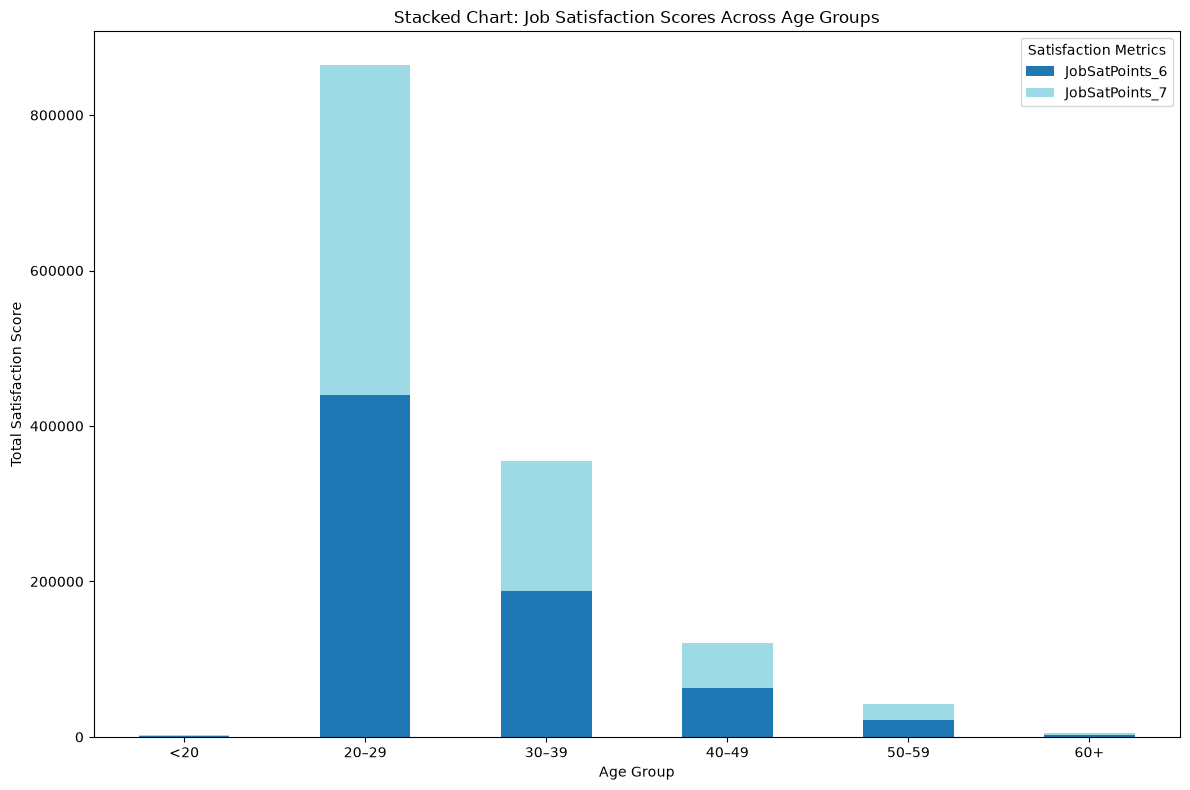

In [7]:
##Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ---------------------------------------------------------
# STEP 1 — Convert Age ranges into numeric groups
# ---------------------------------------------------------
def extract_age(age_str):
    if isinstance(age_str, str):
        nums = re.findall(r'\d+', age_str)
        if len(nums) >= 2:
            return (int(nums[0]) + int(nums[1])) / 2
        elif len(nums) == 1:
            return int(nums[0])
    return np.nan

df['AgeNum'] = df['Age'].apply(extract_age)

# Create age bins
age_bins = [0, 20, 30, 40, 50, 60, 100]
age_labels = ['<20', '20–29', '30–39', '40–49', '50–59', '60+']
df['AgeGroup'] = pd.cut(df['AgeNum'], bins=age_bins, labels=age_labels)

# ---------------------------------------------------------
# STEP 2 — Select satisfaction columns
# ---------------------------------------------------------
sat_cols = ['JobSatPoints_6', 'JobSatPoints_7']
df[sat_cols] = df[sat_cols].apply(pd.to_numeric, errors='coerce')

# ---------------------------------------------------------
# STEP 3 — Group by AgeGroup and count satisfaction levels
# ---------------------------------------------------------
grouped = df.groupby('AgeGroup')[sat_cols].sum()

# ---------------------------------------------------------
# STEP 4 — Stacked bar chart
# ---------------------------------------------------------
plt.figure(figsize=(12,8))

grouped.plot(kind='bar', stacked=True, colormap='tab20', figsize=(12,8))

plt.xlabel("Age Group")
plt.ylabel("Total Satisfaction Score")
plt.title("Stacked Chart: Job Satisfaction Scores Across Age Groups")
plt.xticks(rotation=0)
plt.legend(title="Satisfaction Metrics")
plt.tight_layout()
plt.show()


##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


<Figure size 1600x1000 with 0 Axes>

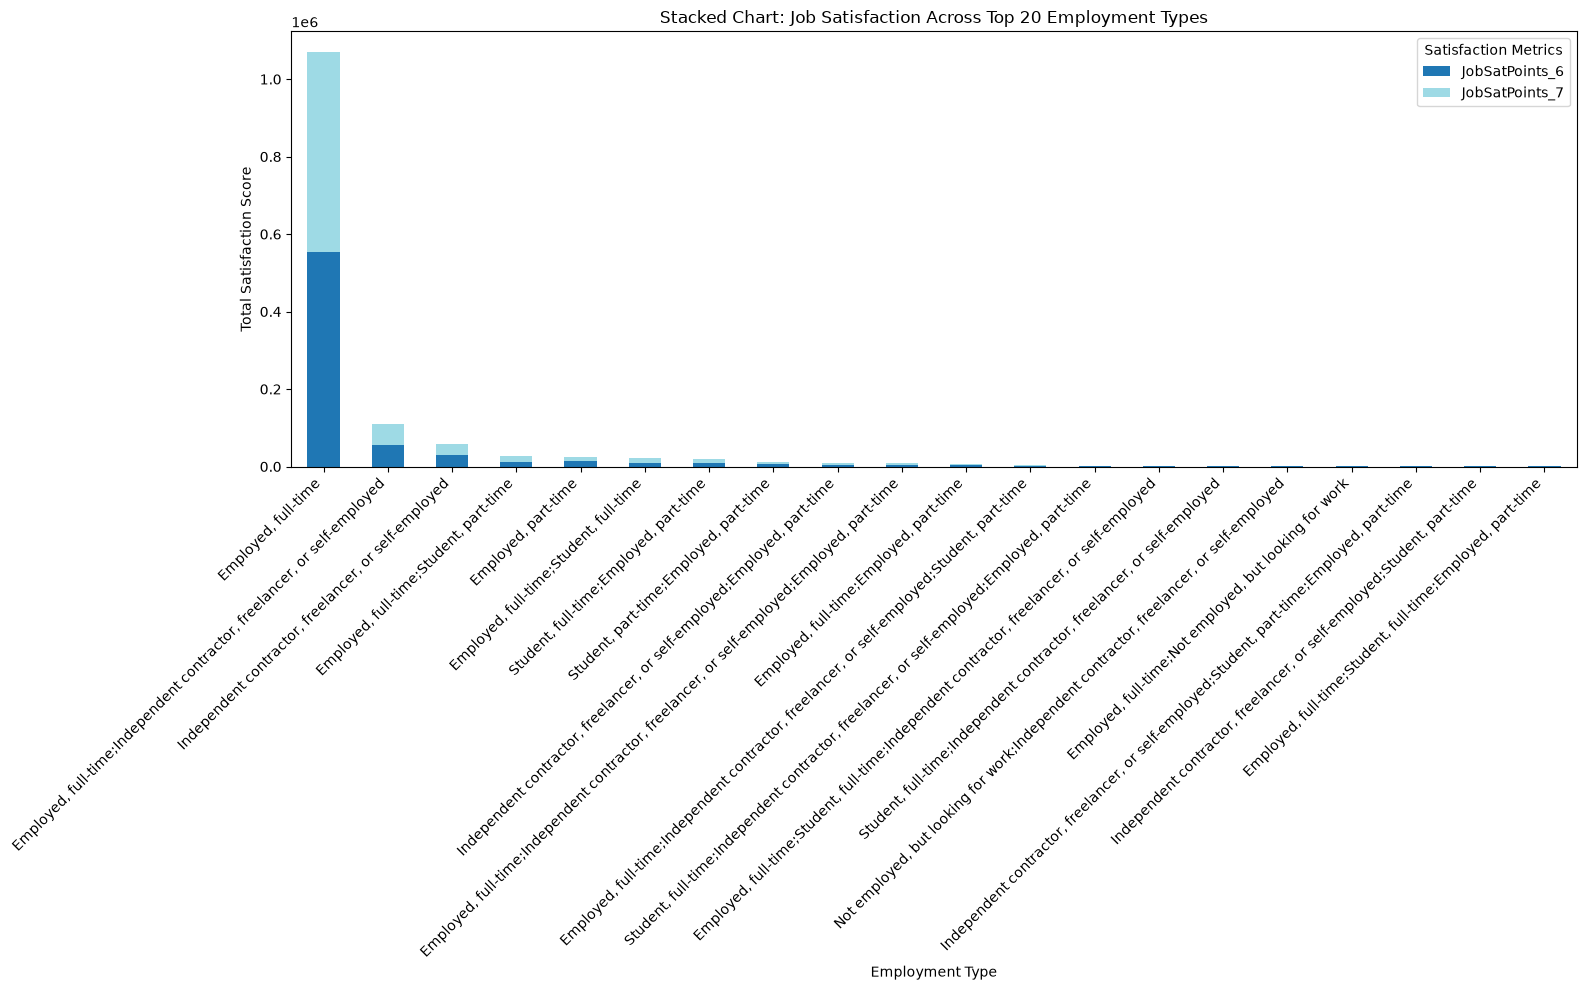

In [11]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1 — Ensure satisfaction columns are numeric
# ---------------------------------------------------------
sat_cols = ['JobSatPoints_6', 'JobSatPoints_7']
df[sat_cols] = df[sat_cols].apply(pd.to_numeric, errors='coerce')

# ---------------------------------------------------------
# STEP 2 — Clean Employment column
# ---------------------------------------------------------
df['Employment'] = df['Employment'].fillna('Unknown')

# ---------------------------------------------------------
# STEP 3 — Group by Employment and sum satisfaction scores
# ---------------------------------------------------------
grouped = df.groupby('Employment')[sat_cols].sum()

# ---------------------------------------------------------
# STEP 4 — Select Top 20 Employment Types
# ---------------------------------------------------------
grouped['Total'] = grouped.sum(axis=1)
top20 = grouped.sort_values('Total', ascending=False).head(20)
top20 = top20.drop(columns=['Total'])

# ---------------------------------------------------------
# STEP 5 — Stacked bar chart with readable labels
# ---------------------------------------------------------
plt.figure(figsize=(16,10))

top20.plot(kind='bar', stacked=True, colormap='tab20', figsize=(16,10))

plt.xlabel("Employment Type")
plt.ylabel("Total Satisfaction Score")
plt.title("Stacked Chart: Job Satisfaction Across Top 20 Employment Types")

# Better x-axis readability
plt.xticks(rotation=45, ha='right')

plt.legend(title="Satisfaction Metrics")
plt.tight_layout()
plt.show()




### Task 2: Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 30-35.


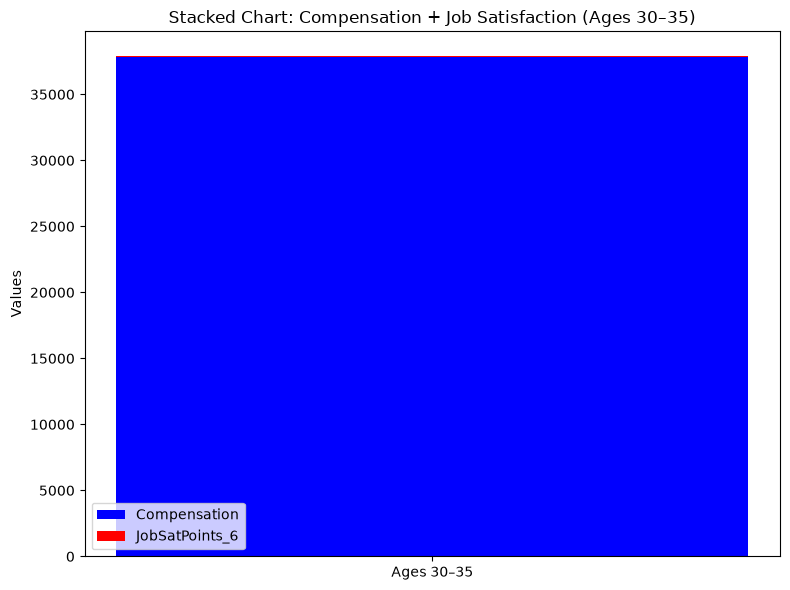

In [22]:
##Write your code here
#stacked chart visualizes the composition of compensation (ConvertedCompYearly) and job satisfaction (JobSatPoints_6) specifically for respondents aged 30-35.
import pandas as pd
import matplotlib.pyplot as plt


import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1 — Filter age ranges that include ages 30–35
# ---------------------------------------------------------
df_30_35 = df[df['Age'].isin(['25-34 years old', '35-44 years old'])]

# ---------------------------------------------------------
# STEP 2 — Clean numeric columns
# ---------------------------------------------------------
cols = ['ConvertedCompYearly', 'JobSatPoints_6']
df_30_35[cols] = df_30_35[cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# ---------------------------------------------------------
# STEP 3 — Compute averages for ONE combined bar
# ---------------------------------------------------------
avg_comp = df_30_35['ConvertedCompYearly'].mean()
avg_sat = df_30_35['JobSatPoints_6'].mean()

# ---------------------------------------------------------
# STEP 4 — Plot ONE stacked bar
# ---------------------------------------------------------
plt.figure(figsize=(8,6))

# Compensation (bottom)
plt.bar('Ages 30–35', avg_comp, color='blue', label='Compensation')

# Job satisfaction (top)
plt.bar('Ages 30–35', avg_sat, bottom=avg_comp, color='red', label='JobSatPoints_6')

plt.ylabel("Values")
plt.title("Stacked Chart: Compensation + Job Satisfaction (Ages 30–35)")
plt.legend()
plt.tight_layout()
plt.show()








##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


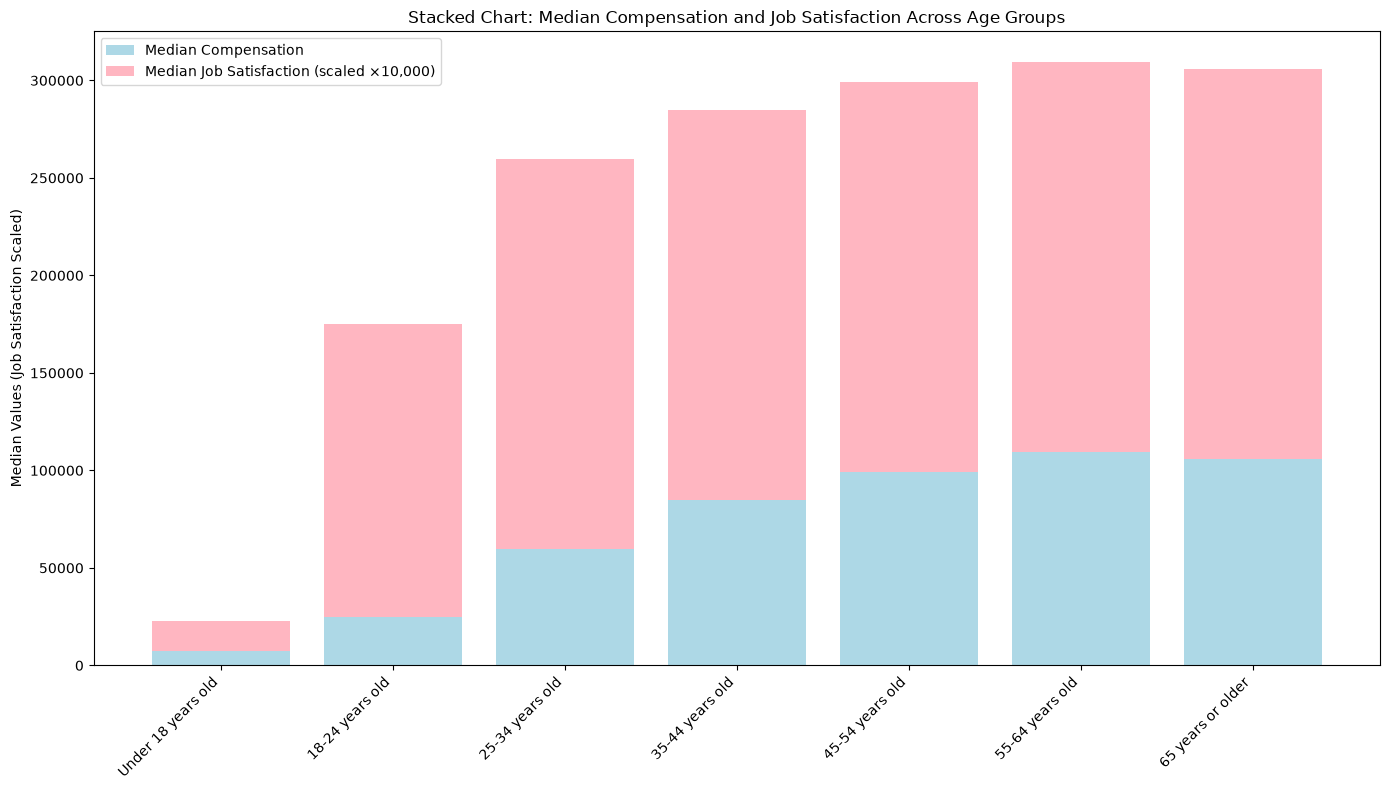

In [25]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

# Clean numeric columns
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Define age groups
age_groups = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Compute medians
median_data = (
    df.groupby('Age')[['ConvertedCompYearly', 'JobSatPoints_6']]
    .median()
    .loc[age_groups]
)

# Scale job satisfaction so it's visible
median_data['JobSatPoints_6_scaled'] = median_data['JobSatPoints_6'] * 10000

# Plot stacked chart with light colors
plt.figure(figsize=(14,8))

plt.bar(
    median_data.index,
    median_data['ConvertedCompYearly'],
    color='#ADD8E6',   # light blue
    label='Median Compensation'
)

plt.bar(
    median_data.index,
    median_data['JobSatPoints_6_scaled'],
    bottom=median_data['ConvertedCompYearly'],
    color='#FFB6C1',   # light pink/red
    label='Median Job Satisfaction (scaled ×10,000)'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Values (Job Satisfaction Scaled)')
plt.title('Stacked Chart: Median Compensation and Job Satisfaction Across Age Groups')
plt.legend()
plt.tight_layout()
plt.show()


### Task 3: Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


<Figure size 1400x800 with 0 Axes>

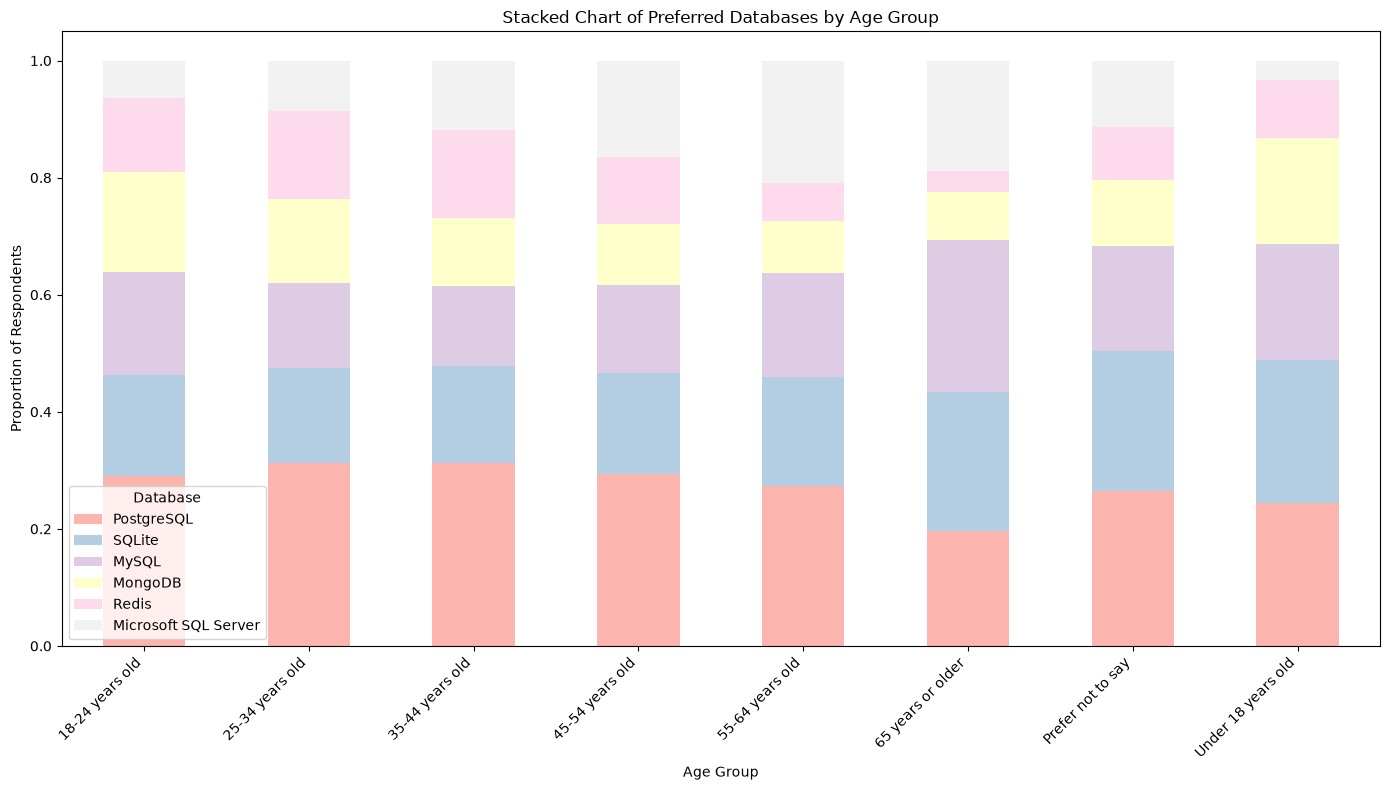

In [29]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df.columns
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1 — Clean database column
# ---------------------------------------------------------
df['DatabaseWantToWorkWith'] = df['DatabaseWantToWorkWith'].fillna('')

# Split multi-select values into lists
df['DB_List'] = df['DatabaseWantToWorkWith'].str.split(';')

# ---------------------------------------------------------
# STEP 2 — Expand rows so each database gets its own row
# ---------------------------------------------------------
df_expanded = df.explode('DB_List')

# Remove blanks
df_expanded = df_expanded[df_expanded['DB_List'].str.strip() != '']

# ---------------------------------------------------------
# STEP 3 — Count database preferences per age group
# ---------------------------------------------------------
db_counts = df_expanded.groupby(['Age', 'DB_List']).size().reset_index(name='Count')

# ---------------------------------------------------------
# STEP 4 — Pivot to wide format
# ---------------------------------------------------------
db_pivot = db_counts.pivot(index='Age', columns='DB_List', values='Count').fillna(0)

# ---------------------------------------------------------
# STEP 5 — Select top databases overall
# ---------------------------------------------------------
top_dbs = db_pivot.sum().sort_values(ascending=False).head(6).index
db_top = db_pivot[top_dbs]

# ---------------------------------------------------------
# STEP 6 — Convert counts to proportions
# ---------------------------------------------------------
db_prop = db_top.div(db_top.sum(axis=1), axis=0)

# ---------------------------------------------------------
# STEP 7 — Plot stacked chart (light colors)
# ---------------------------------------------------------
plt.figure(figsize=(14,8))
db_prop.plot(kind='bar', stacked=True, figsize=(14,8), colormap='Pastel1')

plt.title("Stacked Chart of Preferred Databases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion of Respondents")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Database")
plt.tight_layout()
plt.show()



##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


In [ ]:
##Write your code here

### Task 4: Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


<Figure size 1600x1000 with 0 Axes>

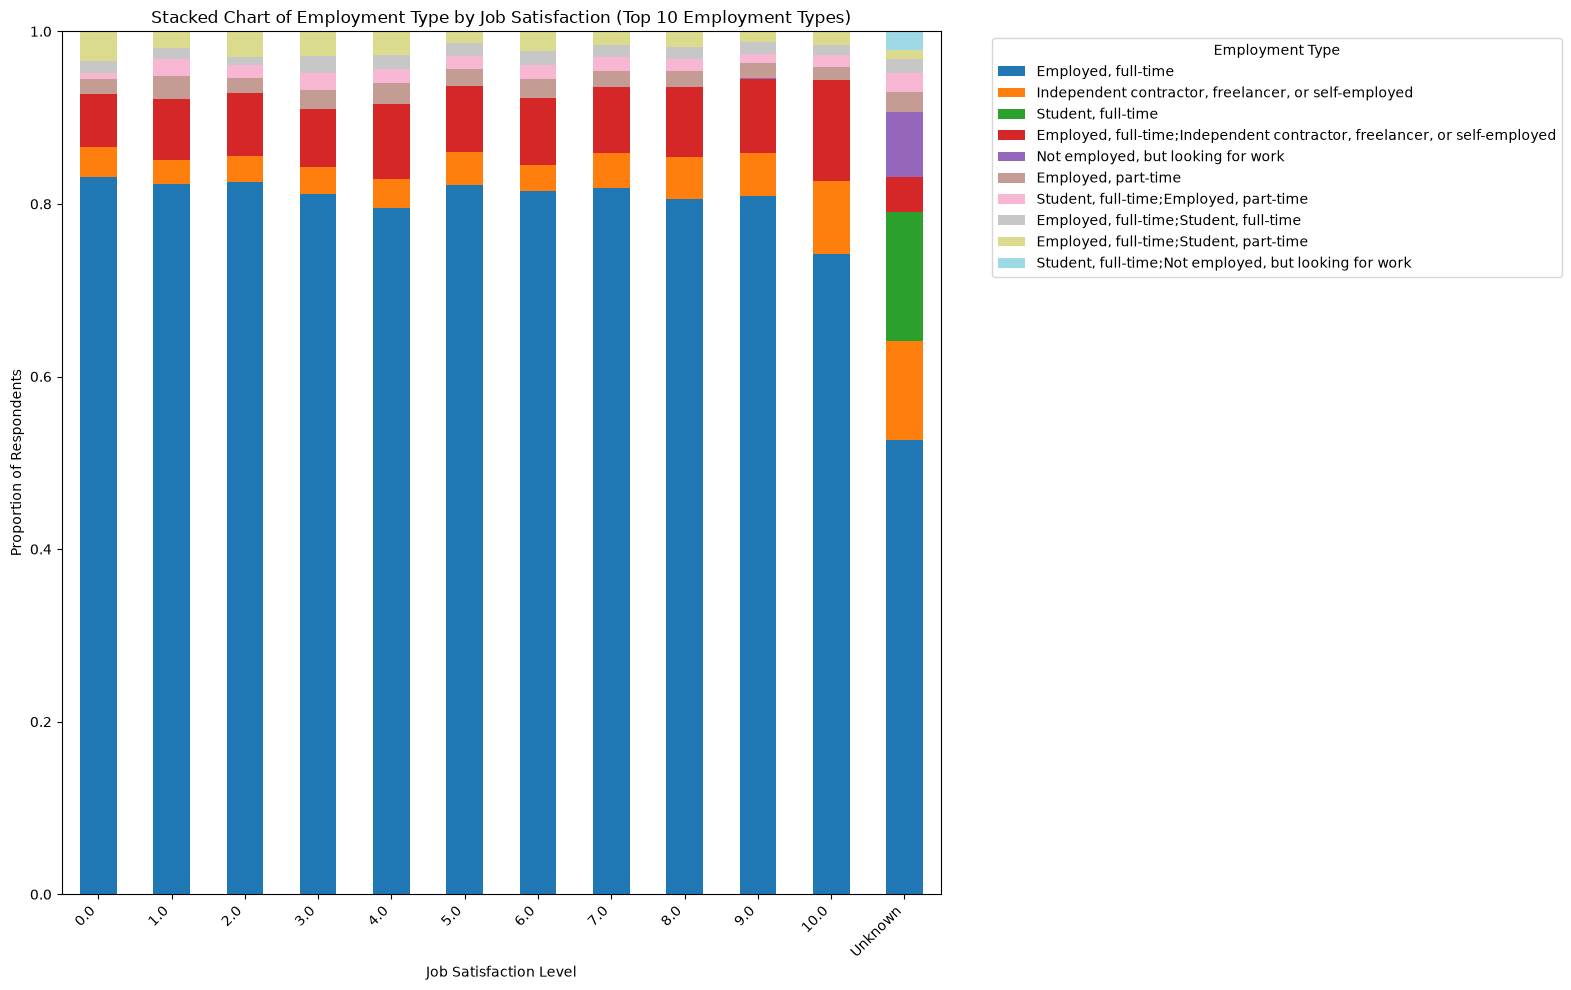

In [32]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1 — Clean columns
# ---------------------------------------------------------
df['Employment'] = df['Employment'].fillna('Unknown')
df['JobSat'] = df['JobSat'].fillna('Unknown')

# ---------------------------------------------------------
# STEP 2 — Count employment types within each satisfaction level
# ---------------------------------------------------------
emp_counts = df.groupby(['JobSat', 'Employment']).size().reset_index(name='Count')

# ---------------------------------------------------------
# STEP 3 — Pivot to wide format
# ---------------------------------------------------------
emp_pivot = emp_counts.pivot(index='JobSat', columns='Employment', values='Count').fillna(0)

# ---------------------------------------------------------
# STEP 4 — Select top 10 employment types overall
# ---------------------------------------------------------
top_10_employment = emp_pivot.sum().sort_values(ascending=False).head(10).index
emp_top = emp_pivot[top_10_employment]

# ---------------------------------------------------------
# STEP 5 — Convert counts to proportions
# ---------------------------------------------------------
emp_prop = emp_top.div(emp_top.sum(axis=1), axis=0)

# ---------------------------------------------------------
# STEP 6 — Plot stacked chart (darker colors, NO labels)
# ---------------------------------------------------------
plt.figure(figsize=(16,10))

emp_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(16,10),
    colormap='tab20'   # darker, more visible colors
)

plt.title("Stacked Chart of Employment Type by Job Satisfaction (Top 10 Employment Types)")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Proportion of Respondents")
plt.xticks(rotation=45, ha='right')

# Legend only — no labels on bars
plt.legend(title="Employment Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()




##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


<Figure size 1800x1200 with 0 Axes>

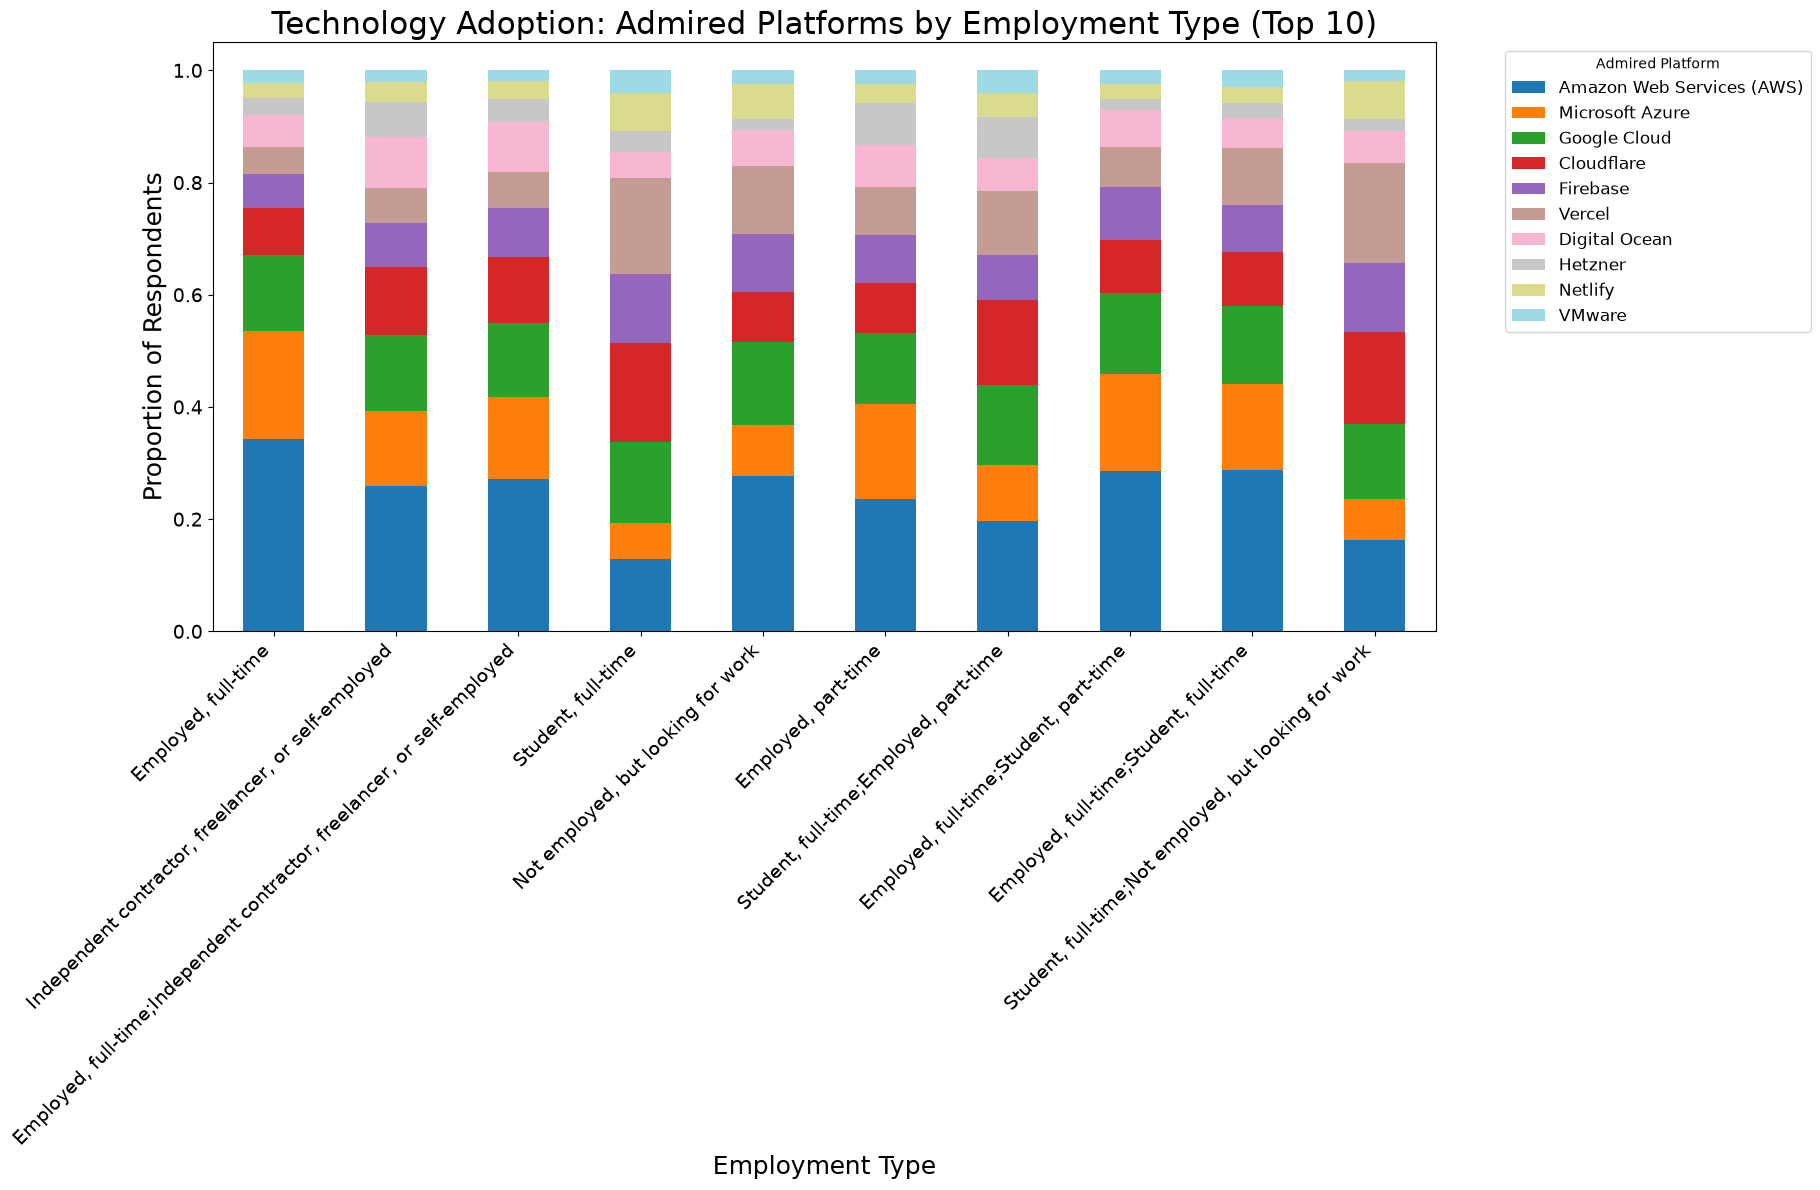

In [34]:
##Write your code here
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1 — Clean columns
# ---------------------------------------------------------
df['Employment'] = df['Employment'].fillna('Unknown')
df['PlatformAdmired'] = df['PlatformAdmired'].fillna('')

# Split multi-select admired platforms
df['Platform_List'] = df['PlatformAdmired'].str.split(';')

# ---------------------------------------------------------
# STEP 2 — Expand rows so each platform gets its own row
# ---------------------------------------------------------
df_expanded = df.explode('Platform_List')

# Remove blanks
df_expanded = df_expanded[df_expanded['Platform_List'].str.strip() != '']

# ---------------------------------------------------------
# STEP 3 — Count platform preferences per employment type
# ---------------------------------------------------------
plat_counts = df_expanded.groupby(['Employment', 'Platform_List']).size().reset_index(name='Count')

# ---------------------------------------------------------
# STEP 4 — Pivot to wide format
# ---------------------------------------------------------
plat_pivot = plat_counts.pivot(index='Employment', columns='Platform_List', values='Count').fillna(0)

# ---------------------------------------------------------
# STEP 5 — Select top 10 employment types
# ---------------------------------------------------------
top_10_employment = plat_pivot.sum(axis=1).sort_values(ascending=False).head(10).index
plat_top_emp = plat_pivot.loc[top_10_employment]

# ---------------------------------------------------------
# STEP 6 — Select top 10 admired platforms overall
# ---------------------------------------------------------
top_10_platforms = plat_top_emp.sum().sort_values(ascending=False).head(10).index
plat_top = plat_top_emp[top_10_platforms]

# ---------------------------------------------------------
# STEP 7 — Convert counts to proportions
# ---------------------------------------------------------
plat_prop = plat_top.div(plat_top.sum(axis=1), axis=0)

# ---------------------------------------------------------
# STEP 8 — Plot stacked chart (darker colors + bigger labels)
# ---------------------------------------------------------
plt.figure(figsize=(18,12))

plat_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(18,12),
    colormap='tab20'   # darker, more visible colors
)

plt.title("Technology Adoption: Admired Platforms by Employment Type (Top 10)", fontsize=22)
plt.xlabel("Employment Type", fontsize=18)
plt.ylabel("Proportion of Respondents", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)

# Legend only — no labels on bars
plt.legend(title="Admired Platform", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


### Final Step: Review


In this lab, you focused on using stacked charts to understand the composition and comparison within the dataset. Stacked charts provided insights into job satisfaction, compensation, and preferred databases across age groups and employment types.


## Summary


After completing this lab, you will be able to:

- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.


## Author:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
